<a href="https://colab.research.google.com/github/vitorjensen/Martech/blob/main/Data%20Science%20para%20Marketing/Analisando%20e%20Explorando%20Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Anotações Aula 1 - Conhecendo os Dados

In [ ]:
nome_influenciador = "Vitor"
print(nome_influenciador)

Vitor


####Importando bibliotecas padrão

In [ ]:
import pandas as pd
import seaborn as sns

####Criando um dataframe para ser lido o CSV de dados

In [ ]:
campanha = pd.read_csv("/content/campanha.csv")

#### Usando comando Shape para mostrar as dimensões da tabela

In [ ]:
campanha.shape

(50000, 8)

####Usando função head() para exibir apenas as 5 linhas iniciais do dataframe

In [ ]:
campanha.head()

,Id_campanha,impressoes,cliques,canal,custo,receita,estado,pais
0,1,152431,9462,Email,13258,32309,MG,Brasil
1,1,39688,3218,PPC,16391,16568,BA,Brasil
2,1,104506,4756,Google Ads,6189,19029,AL,Brasil
3,1,80768,3566,Google Ads,5215,0,PI,Brasil
4,1,54932,3645,Google Ads,16767,8825,RJ,Brasil


####Filtrando o dataframe apenas pela coluna "canal"

In [ ]:
campanha['canal']

,canal
0,Email
1,PPC
2,Google Ads
3,Google Ads
4,Google Ads
...,...
49995,Social Media
49996,Google Ads
49997,Google Ads
49998,PPC


####Usando função unique() para poder exibir valores únicos do campo 'canal'

In [ ]:
campanha['canal'].unique()

array(['Email', 'PPC', 'Google Ads', 'Meta Ads', 'Social Media'],
      dtype=object)

####Usando a função value_counts() na coluna 'cana' para poder contar os números por canal

In [ ]:
campanha['canal'].value_counts()

,count
canal,
Google Ads,25146
Meta Ads,15009
Social Media,4874
PPC,2526
Email,2445


####Criando novo campo para calcular a Métrica CTR (cliques/impressões)

In [ ]:
campanha['ctr']=(campanha['cliques']/campanha['impressoes'])*100
campanha.head()

,Id_campanha,impressoes,cliques,canal,custo,receita,estado,pais,ctr
0,1,152431,9462,Email,13258,32309,MG,Brasil,6.207399
1,1,39688,3218,PPC,16391,16568,BA,Brasil,8.108244
2,1,104506,4756,Google Ads,6189,19029,AL,Brasil,4.550935
3,1,80768,3566,Google Ads,5215,0,PI,Brasil,4.415115
4,1,54932,3645,Google Ads,16767,8825,RJ,Brasil,6.635477


####Após a criação da coluna 'ctr', utilizamos o describe() para mostrar um panorama das "Medidas De Tendências Centrais" (Media, Moda e Mediana) e "Medida de Dispersão" (Desvio Padrão).

In [ ]:
campanha["ctr"].describe()

,ctr
count,50000.000000
mean,5.148482
std,1.604119
min,0.992663
25%,4.050781
50%,5.132384
75%,6.241502
max,10.000000


####Utilizando o SeaBorn para exibir os dados do ctr em um boxplot

<Axes: ylabel='ctr'>

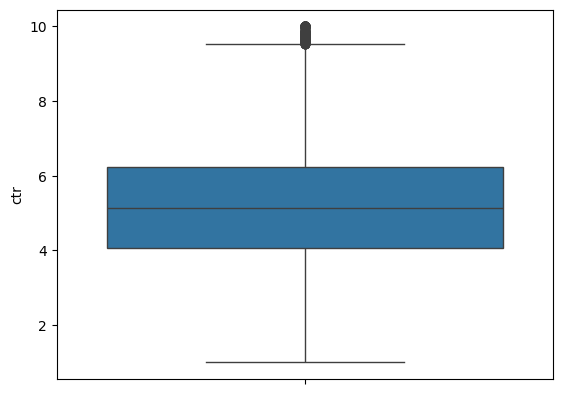

In [ ]:
sns.boxplot(campanha["ctr"])

##Anotações Aula 2 - Analisando os Dados:

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Usando Query

In [ ]:
campanha = pd.read_csv("/content/campanha.csv")

#### Filtrando campanhas com ID 1 apenas. Passar parâmetro "numeric_only=true"

In [ ]:
campanha.query('Id_campanha == 1').mean(numeric_only=True)

,0
Id_campanha,1.000000
impressoes,96580.806452
cliques,4902.096774
custo,13863.419355
receita,14000.806452


####Filtrando campanhas com ID 1 apenas + o campo de impressões e tirando a média

In [ ]:
campanha.query('Id_campanha == 1')['impressoes'].mean()

np.float64(96580.80645161291)

####Fazendo uma análise segmentada utilizando o GROUPBY e guardando a query numa variável

In [ ]:
medias_por_campanha = campanha.groupby('Id_campanha')['impressoes'].mean()
medias_por_campanha.head()

,impressoes
Id_campanha,
1,96580.806452
2,92372.923077
3,118489.333333
4,96947.681818
5,105508.291667


#### Exibindo o groupby utilizando um histograma

<Axes: ylabel='Frequency'>

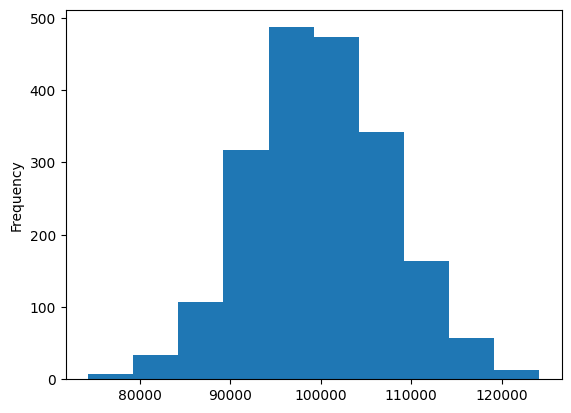

In [ ]:
medias_por_campanha.plot(kind='hist')

#### Utilizando o GROUPBY para fazer uma analise segmentada agora usando os campos "canal" e "ctr"

In [ ]:
campanha['ctr']=(campanha['cliques']/campanha['impressoes'])*100

In [ ]:
metricas_por_tipo = campanha.groupby('canal')['ctr'].mean()
metricas_por_tipo.head()

,ctr
canal,
Email,5.109386
Google Ads,5.152163
Meta Ads,5.133841
PPC,5.162208
Social Media,5.187068


####Utilizando o Displot (Seaborn) e Marplotlib para visualizar as informações. Uso do Discribe

In [ ]:
medias_por_campanha.describe()

,impressoes
count,2000.000000
mean,99924.847399
std,7651.690148
min,74315.388889
25%,94601.752717
50%,99731.860577
75%,105173.546176
max,124154.071429


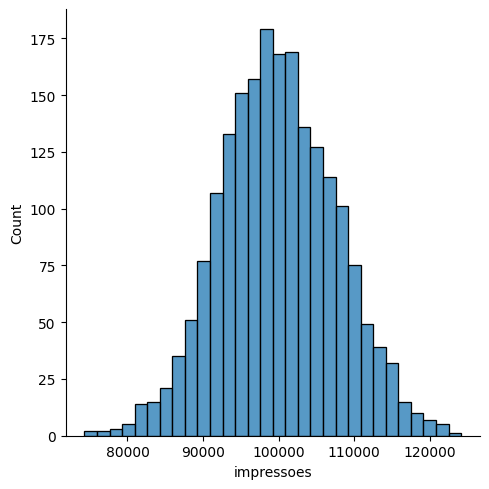

In [ ]:
sns.displot(medias_por_campanha)

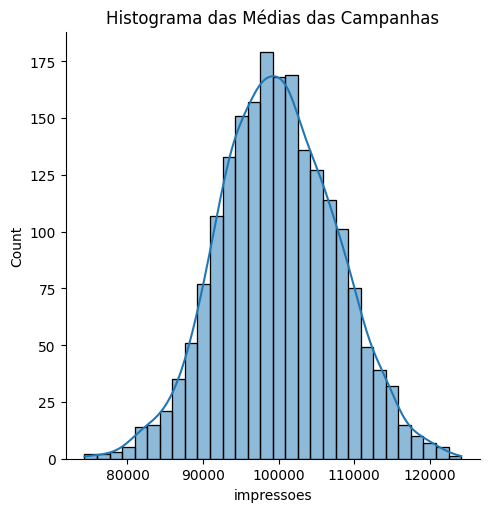

In [ ]:
sns.displot(medias_por_campanha, kde = True)
plt.title('Histograma das Médias das Campanhas')
plt.show()